In [8]:
import os
import pandas as pd
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

# 1. Trỏ đường dẫn tới thư mục artifacts chứa dữ liệu đã xử lý
# Dùng '..' để lùi từ thư mục 'notebooks' ra thư mục gốc
ARTIFACTS_DIR = os.path.join('..', 'artifacts')

print(f"📂 Đang nạp dữ liệu từ: {ARTIFACTS_DIR}")

# 2. Đọc dữ liệu Train/Test đã được xử lý hoàn chỉnh từ file .py
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test.csv'))

# y_train và y_test đọc vào dưới dạng Pandas Series (lấy cột Churn)
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv'))['Churn']
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test.csv'))['Churn']

print(f"✅ Đã nạp thành công! Kích thước X_train: {X_train.shape}")
# Hiển thị thử 3 dòng đầu để kiểm tra tên cột
X_train.head(3)

📂 Đang nạp dữ liệu từ: ..\artifacts
✅ Đã nạp thành công! Kích thước X_train: (5634, 25)


,encoder__Dependents_Yes,encoder__PaymentMethod_Credit card (automatic),encoder__PaymentMethod_Electronic check,encoder__PaymentMethod_Mailed check,encoder__InternetService_Fiber optic,encoder__InternetService_No,encoder__tenure_group_13-24 months,encoder__tenure_group_25-36 months,encoder__tenure_group_37-48 months,encoder__tenure_group_49-60 months,...,remainder__PaperlessBilling,remainder__MonthlyCharges,remainder__TotalCharges,remainder__OnlineSecurity,remainder__OnlineBackup,remainder__DeviceProtection,remainder__TechSupport,remainder__service_diversity,remainder__monthly_charges_ratio,remainder__is_paperless_electronic
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1,94.10,5475.9,1,1,0,0,2,1.453019,1
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0,19.35,212.3,0,0,0,0,0,0.298788,0
2,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,1,80.45,137.1,1,0,1,0,2,1.242247,0


📂 Đang nạp dữ liệu từ: ..\artifacts
✅ Đã nạp thành công! Kích thước X_train: (5634, 25)

🚀 Đang huấn luyện mô hình Logistic Regression...


c:\Users\Muich\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


✅ Huấn luyện thành công!

📊 KẾT QUẢ ĐÁNH GIÁ HIỆU SUẤT (TẬP TEST):
   🔹 Accuracy  : 0.7537
   🔹 Precision : 0.5234
   🔹 Recall    : 0.8075
   🔹 F1-score  : 0.6351
   🔹 ROC-AUC   : 0.8502

📋 Chi tiết Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1035
           1       0.52      0.81      0.64       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.77      1409



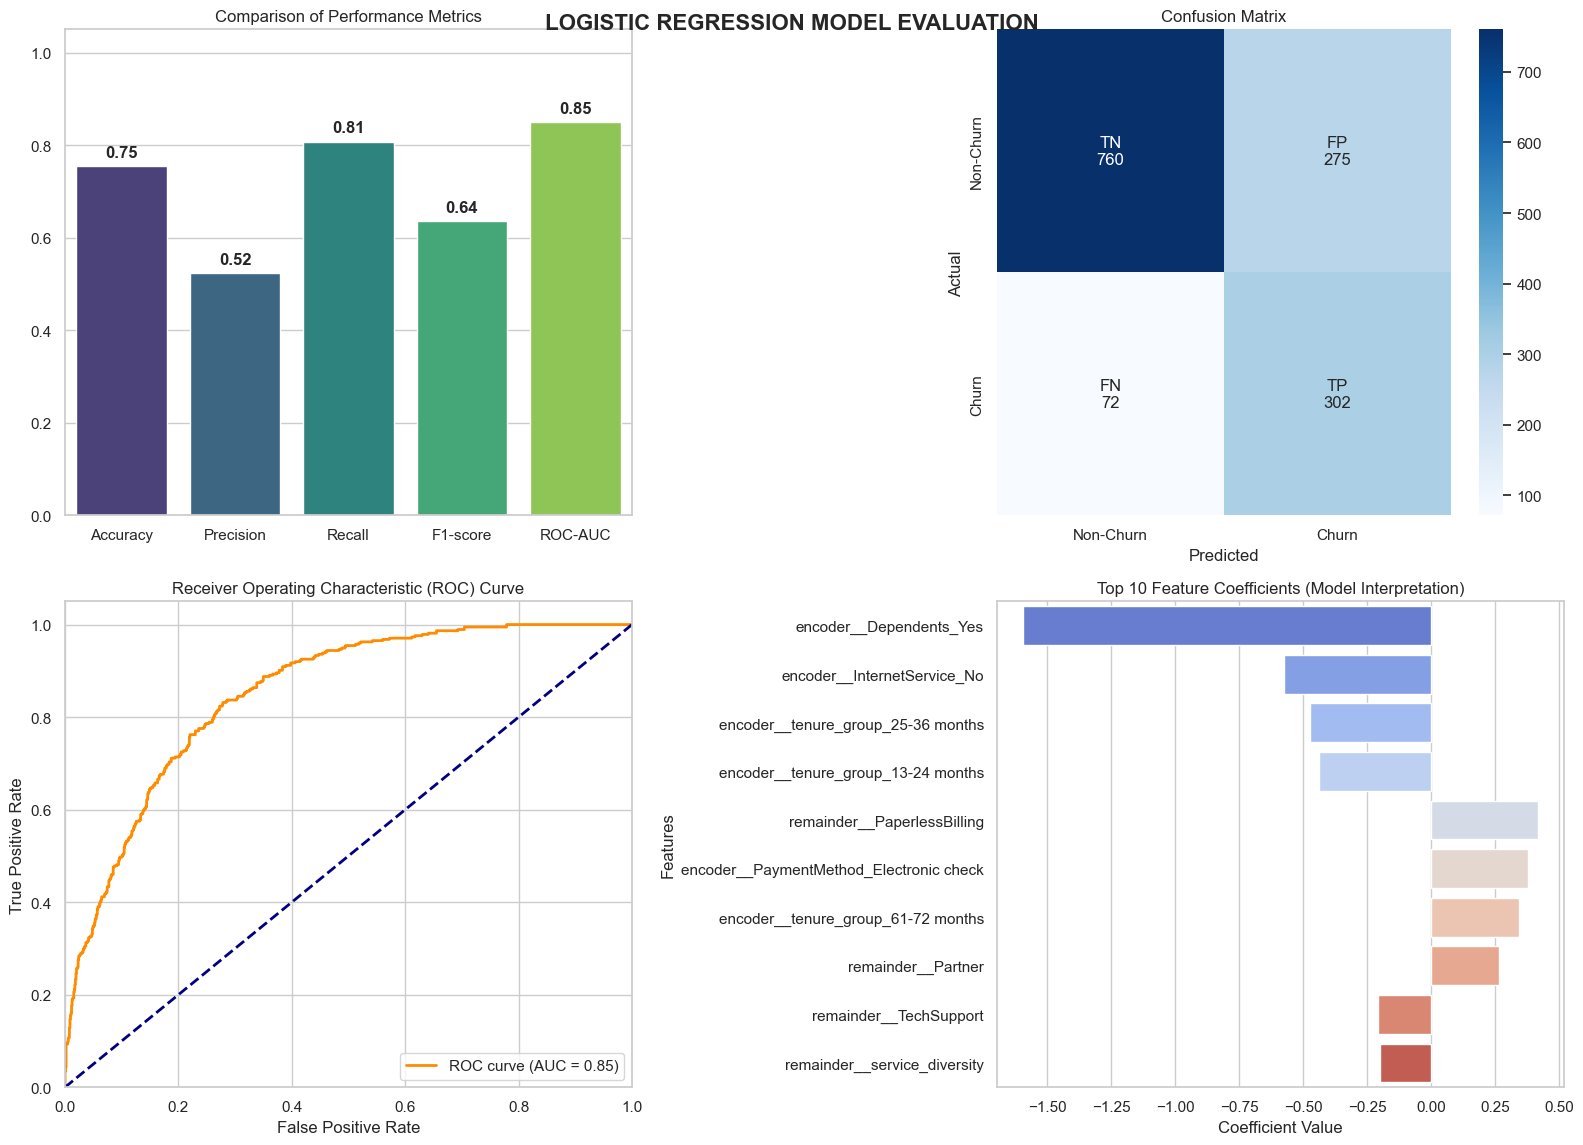

💾 Đã đóng gói và lưu mô hình tại: ..\artifacts\logistic_regression_model.joblib
📊 Đã xuất danh sách trọng số đặc trưng phục vụ báo cáo: ..\artifacts\logistic_regression_coefficients.csv


In [9]:
import os
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đầy đủ thư viện của sklearn để tránh lỗi 'not defined'
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve)

# =====================================================================
# BƯỚC 1: NẠP DỮ LIỆU TỪ THƯ MỤC ARTIFACTS
# =====================================================================
# Dùng '..' để lùi từ thư mục 'notebooks' ra thư mục gốc
ARTIFACTS_DIR = os.path.join('..', 'artifacts')
print(f"📂 Đang nạp dữ liệu từ: {ARTIFACTS_DIR}")

# Đọc dữ liệu Train/Test đã được xử lý hoàn chỉnh từ file .csv
X_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'X_test.csv'))

# y_train và y_test đọc vào dưới dạng Pandas Series (lấy cột Churn)
y_train = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_train.csv'))['Churn']
y_test = pd.read_csv(os.path.join(ARTIFACTS_DIR, 'y_test.csv'))['Churn']

print(f"✅ Đã nạp thành công! Kích thước X_train: {X_train.shape}")


# =====================================================================
# BƯỚC 2: HUẤN LUYỆN MÔ HÌNH LOGISTIC REGRESSION (BASELINE MODEL)
# =====================================================================
print("\n🚀 Đang huấn luyện mô hình Logistic Regression...")
# Khởi tạo mô hình với max_iter lớn để đảm bảo hội tụ, class_weight='balanced' để tối ưu Recall
model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
model.fit(X_train, y_train)
print("✅ Huấn luyện thành công!")

# Dự đoán trên tập Test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Xác suất cho lớp Churn (1)


# =====================================================================
# BƯỚC 3: TÍNH TOÁN VÀ IN 5 METRICS CỐT LÕI
# =====================================================================
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall': recall_score(y_test, y_pred), # Chỉ số ưu tiên giảm thiểu False Negative của dự án
    'F1-score': f1_score(y_test, y_pred),
    'ROC-AUC': roc_auc_score(y_test, y_pred_proba)
}

print("\n📊 KẾT QUẢ ĐÁNH GIÁ HIỆU SUẤT (TẬP TEST):")
for metric_name, val in metrics.items():
    print(f"   🔹 {metric_name:<10}: {val:.4f}")

print("\n📋 Chi tiết Classification Report:")
print(classification_report(y_test, y_pred))


# =====================================================================
# BƯỚC 4: TRỰC QUAN HÓA CÁC ĐỒ THỊ THEO YÊU CẦU (4-IN-1)
# =====================================================================
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('LOGISTIC REGRESSION MODEL EVALUATION', fontsize=16, fontweight='bold', y=0.95)

# Đồ thị 1: Biểu đồ cột so sánh 5 Metrics
sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), ax=axes[0, 0], palette='viridis', hue=list(metrics.keys()), legend=False)
axes[0, 0].set_title('Comparison of Performance Metrics')
axes[0, 0].set_ylim(0, 1.05)
for i, val in enumerate(metrics.values()):
    axes[0, 0].text(i, val + 0.02, f'{val:.2f}', ha='center', fontweight='bold')

# Đồ thị 2: Confusion Matrix (Ma trận nhầm lẫn)
cm = confusion_matrix(y_test, y_pred)
# Xử lý nhãn hiển thị trực tiếp dạng ma trận chuỗi
labels = np.array([
    [f"TN\n{cm[0,0]}", f"FP\n{cm[0,1]}"],
    [f"FN\n{cm[1,0]}", f"TP\n{cm[1,1]}"]
])
sns.heatmap(cm, annot=labels, fmt='', cmap='Blues', ax=axes[0, 1],
            xticklabels=['Non-Churn', 'Churn'], yticklabels=['Non-Churn', 'Churn'])
axes[0, 1].set_title('Confusion Matrix')
axes[0, 1].set_xlabel('Predicted')
axes[0, 1].set_ylabel('Actual')

# Đồ thị 3: Đường cong ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1, 0].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {metrics["ROC-AUC"]:.2f})')
axes[1, 0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[1, 0].legend(loc="lower right")

# Đồ thị 4: Feature Importance qua Coefficients (Hệ số hồi quy)
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

sns.barplot(x='Coefficient', y='Feature', data=coef_df, ax=axes[1, 1], palette='coolwarm', hue='Feature', legend=False)
axes[1, 1].set_title('Top 10 Feature Coefficients (Model Interpretation)')
axes[1, 1].set_xlabel('Coefficient Value')
axes[1, 1].set_ylabel('Features')

plt.tight_layout()
plt.show()


# =====================================================================
# BƯỚC 5: ĐÓNG GÓI SẢN PHẨM & XUẤT FILE PHỤC VỤ BÁO CÁO LA-TEX
# =====================================================================
# Tạo thư mục artifacts nếu chưa tồn tại (đề phòng)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

model_path = os.path.join(ARTIFACTS_DIR, 'logistic_regression_model.joblib')
joblib.dump(model, model_path)
print(f"💾 Đã đóng gói và lưu mô hình tại: {model_path}")

coef_all_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coef_csv_path = os.path.join(ARTIFACTS_DIR, 'logistic_regression_coefficients.csv')
coef_all_df.to_csv(coef_csv_path, index=False)
print(f"📊 Đã xuất danh sách trọng số đặc trưng phục vụ báo cáo: {coef_csv_path}")